In [ ]:

#พื้นที่นำเข้าสิ่งที่ต้องใช้ทั้งหมด
#พื้นฐาน
import numpy as np
import pandas as pd

#ทำ EDA
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

#ทำ model
import statsmodels.formula.api as sm
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

นำเข้าข้อมูล

In [ ]:
restaurant = pd.read_csv("Restaurant.csv")
restaurant

In [ ]:
#ข้อมูลใน csv
restaurant.info()  #แสดงประเภทข้อมูล (Data Types) และจำนวน Non-Null   

จากผลลัพธ์การตรวจสอบข้อมูล แสดงให้เห็นว่า
1. ข้อมูลอยู่ในรูป dataframe
2. มีข้อมูลทั้งหมด 254 แถว 10 columns 
3. ข้อมูลแต่ละ Columns ไม่มีข้อมูลใดที่เป็นช่องว่าง
4. Date ถูกเก็บในรูปแบบ str ทำให้ไม่สามารถนำมากรองเป็นวันที่ได้
5. ค่า quantity ถูกเก็บเป็น float แต่จำนวนชิ้นในการขายควรเป็นจำนวณเต็ม

แปลง quantity

In [41]:
restaurant['Quantity'] = restaurant['Quantity'].round().astype(int)
restaurant.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City
0,10452,7-11-2022,Fries,3.49,573,Online,Gift Card,Tom Jackson,London
1,10453,7-11-2022,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid
2,10454,7-11-2022,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon
3,10455,8-11-2022,Burgers,12.99,570,In-store,Credit Card,Walter Muller,Berlin
4,10456,8-11-2022,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin


In [42]:
#ตรวจสอบรูปแบบของข้อมูล Date
restaurant['Date'].sample(10)
#พบว่ารูปแบบของวันที่ มีหลาายรูปแบบ ต้องเปลี่ยนให้เป็นรูปแบบเดียวกันเพื่อให้สามารถกรองข้อมูลวันที่ได้ในอนาคต

174    13-12-2022
244    27-12-2022
33     15-11-2022
155    10-12-2022
166    12-12-2022
228    24-12-2022
182    15-12-2022
51     18-11-2022
87     26-11-2022
61     13-11-2022
Name: Date, dtype: str

In [43]:
#Date column to datetime
#เปลี่ยนเครื่องหมาย / ให้เป็น - ทั้งหมด กรณีที่แปลงแล้ว โค้ดจะ Error เพราะหา / ไม่เจอ
restaurant['Date'] = restaurant['Date'].str.replace('/', '-')

In [44]:
#บันทึกไฟล์แยกเพื่อนับว่าไฟล์นี้เป็นไฟล์สำหรับทำงานต่อ เพื่อไม่ให้่ยุ่งเกี่ยวกับไฟล์ข้อมูลหลัก
restaurant.to_csv('C_Restaurant.csv', index=False)
print("save file success")

save file success


In [45]:
#ดึงไฟล์ที่เปลี่ยนเครื่องหมายแล้วมาใช้งานต่อ
CleanR = pd.read_csv("C_Restaurant.csv")
CleanR['Date'] = pd.to_datetime(restaurant['Date'], format='%d-%m-%Y')  #format='%d-%m-%Y' คือ บอกว่าข้อมูลถูกเรียงรูปแบบไหน
# เปลี่ยนรูปแบบข้อมูลของ date จาก str ให้เป็น Datetime
CleanR.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Order ID        254 non-null    int64         
 1   Date            254 non-null    datetime64[us]
 2   Product         254 non-null    str           
 3   Price           254 non-null    float64       
 4   Quantity        254 non-null    int64         
 5   Purchase Type   254 non-null    str           
 6   Payment Method  254 non-null    str           
 7   Manager         254 non-null    str           
 8   City            254 non-null    str           
dtypes: datetime64[us](1), float64(1), int64(2), str(5)
memory usage: 18.0 KB


In [46]:
# สร้างฟ๊เจอร์แยกวัน เดือน และวันหยุด เพื่อวิเคราะห์ยอดขาายและพฤติกรรมของแต่ละช่วงเวลา  ไม่พิจารณาปี เนื่องจากข้อมูลที่มี มีเพียงสองเดือนของปี 2022
#แยกข้อมูลเดือน
CleanR['Month'] = CleanR['Date'].dt.month
#แยกวันที่ในเดือน
CleanR['Day'] = CleanR['Date'].dt.day
#แยกแต่ละวันในสัปดาห์ และต่อเนื่องไปถึงการวิเคราะห์ช่วงเวลาวันหยุด
CleanR['DayOfWeek'] = CleanR['Date'].dt.dayofweek  # 0=Monday, 6=Sunday
#ตรวจสอบวันหยุด เสาร์อาทิตย์ = 1, อื่น ๆ 0
CleanR['IsWeekend'] = CleanR['DayOfWeek'].isin([5, 6]).astype(int)

print(CleanR[['Date', 'Month', 'Day', 'DayOfWeek', 'IsWeekend']].sample(10))

          Date  Month  Day  DayOfWeek  IsWeekend
63  2022-11-21     11   21          0          0
174 2022-12-13     12   13          1          0
36  2022-11-15     11   15          1          0
205 2022-12-20     12   20          1          0
219 2022-12-22     12   22          3          0
177 2022-12-14     12   14          2          0
61  2022-11-13     11   13          6          1
55  2022-11-19     11   19          5          1
95  2022-11-28     11   28          0          0
176 2022-12-14     12   14          2          0


การแปรผลลัพธ์
วันที่่ 21 เดือน 12 เป็นวันพุธ ซึ่งไม่ใช่วันหยุด ค่า IsWeekend เป็น 0
วันที่่ 27 เดือน 11 เป็นวันอาทิตย์ ซึ่งเป็นวันหยุด ค่า IsWeekend เป็น 1

In [47]:
CleanR.head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Month,Day,DayOfWeek,IsWeekend
0,10452,2022-11-07,Fries,3.49,573,Online,Gift Card,Tom Jackson,London,11,7,0,0
1,10453,2022-11-07,Beverages,2.95,746,Online,Gift Card,Pablo Perez,Madrid,11,7,0,0
2,10454,2022-11-07,Sides & Other,4.99,200,In-store,Gift Card,Joao Silva,Lisbon,11,7,0,0
3,10455,2022-11-08,Burgers,12.99,570,In-store,Credit Card,Walter Muller,Berlin,11,8,1,0
4,10456,2022-11-08,Chicken Sandwiches,9.95,201,In-store,Credit Card,Walter Muller,Berlin,11,8,1,0


In [48]:
#ตรวจสอบ missing values
CleanR[CleanR.isnull().any(axis=1)].head()

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Month,Day,DayOfWeek,IsWeekend


In [49]:
#ตรวจหาข้อมูลซ้ำ
CleanR.duplicated().sum()

np.int64(0)

In [50]:
#ตรวจหาค่า Unique เพื่อตรวจสอบการไม่ซ้ำหรือ Null ของข้อมูลเพิ่มเติม
CleanR['Product'].unique()

<StringArray>
['Fries', 'Beverages', 'Sides & Other', 'Burgers', 'Chicken Sandwiches']
Length: 5, dtype: str

In [51]:
CleanR['Purchase Type'].unique()

<StringArray>
['Online ', 'In-store ', 'Drive-thru ']
Length: 3, dtype: str

In [52]:
CleanR['Payment Method'].unique()

<StringArray>
[' Gift Card', ' Credit Card', ' Cash']
Length: 3, dtype: str

In [53]:
CleanR['Manager'].unique()

<StringArray>
[  'Tom      Jackson', '       Pablo Perez',      'Joao    Silva',
      'Walter Muller',      'Remy    Monet',         'Remy Monet',
  '       Remy Monet',     'Remy     Monet',        'Pablo Perez',
      'Pablo   Perez',       'Pablo  Perez',     'Pablo    Perez',
         'Joao Silva',        'Tom Jackson']
Length: 14, dtype: str

In [54]:
CleanR['City'].unique()

<StringArray>
['London', 'Madrid', 'Lisbon', 'Berlin', 'Paris']
Length: 5, dtype: str

พบว่า Manager มีข้อมูลซ้ำ แต่นับว่า Unique เนื่องจากการเว้นวรรคช่องว่าง รวมถึง Purchase Type และ Payment Method มีช่องว่างที่ไม่จำเป็น ซึ่งอาจทำให้เกิดปัญหาเมื่อต้องใช้งาน ต้องจัดการกับช่องว่าง

In [55]:
# ใช้ Regex เพื่อยุบช่องว่างที่เกินกว่า 1 ช่องให้เหลือช่องว่างเดียว
text_columns = ['Purchase Type', 'Payment Method', 'Manager']
for col in text_columns:
   CleanR[col] = CleanR[col].str.replace(r'\s+', ' ', regex=True).str.strip()
# ตรวจสอบความถูกต้อง
print(CleanR['Purchase Type'].unique())
print(CleanR['Payment Method'].unique())
print(CleanR['Manager'].unique())

<StringArray>
['Online', 'In-store', 'Drive-thru']
Length: 3, dtype: str
<StringArray>
['Gift Card', 'Credit Card', 'Cash']
Length: 3, dtype: str
<StringArray>
['Tom Jackson', 'Pablo Perez', 'Joao Silva', 'Walter Muller', 'Remy Monet']
Length: 5, dtype: str


ตรวจสอบค่าทางสถิติ

In [56]:
CleanR.describe()

,Order ID,Date,Price,Quantity,Month,Day,DayOfWeek,IsWeekend
count,254.000000,254,254.000000,254.000000,254.000000,254.000000,254.000000,254.000000
mean,10584.133858,2022-12-03 10:23:37.322834,7.102323,460.480315,11.555118,16.779528,2.842520,0.251969
min,10452.000000,2022-11-07 00:00:00,2.950000,200.000000,11.000000,1.000000,0.000000,0.000000
25%,10520.250000,2022-11-21 00:00:00,3.490000,201.000000,11.000000,11.000000,1.000000,0.000000
50%,10583.500000,2022-12-03 00:00:00,4.990000,539.000000,12.000000,17.000000,3.000000,0.000000
75%,10649.750000,2022-12-16 18:00:00,9.950000,677.000000,12.000000,23.750000,4.750000,0.750000
max,10713.000000,2022-12-29 00:00:00,29.050000,754.000000,12.000000,30.000000,6.000000,1.000000
std,75.889181,NaN,4.341855,214.979431,0.497934,7.884957,1.955736,0.435000


ค่า Price มีการดีดสูงขึ้นผิดปกติ

In [57]:
CleanR.groupby('Product')['Price'].value_counts()

Product             Price
Beverages           2.95     50
Burgers             12.99    52
Chicken Sandwiches  9.95     51
                    29.05     1
Fries               3.49     50
                    25.50     1
Sides & Other       4.99     49
Name: count, dtype: int64

ราคา Chicken Sandwiches และ Fries มี ราคา ผิดปกติ 1 รายงาน แต่ สินค้าชื่อเดียวกันควรจะมีราคาต่อหน่วยเท่ากันทุกออเดอร์ ต้องแก้ไขราคาต่อหน่วยที่ผิดปกติ

In [58]:
standard_prices = { 'Beverages': 2.95,
                     'Burgers': 12.99,
                     'Chicken Sandwiches': 9.95,
                     'Fries': 3.49,
                     'Sides & Other': 4.99
                   }

CleanR['Price'] = CleanR['Product'].map(standard_prices)

In [59]:
CleanR.groupby('Product')['Price'].value_counts()

Product             Price
Beverages           2.95     50
Burgers             12.99    52
Chicken Sandwiches  9.95     52
Fries               3.49     51
Sides & Other       4.99     49
Name: count, dtype: int64

In [60]:
CleanR[['Price']].describe()

,Price
count,254.000000
mean,6.940472
std,3.958186
min,2.950000
25%,3.490000
50%,4.990000
75%,9.950000
max,12.990000


เพิ่มข้อมูล Revenue ที่ต้องนำไปพิจารณา

In [61]:
CleanR['Revenue'] = CleanR['Price'] * CleanR['Quantity']
CleanR.sample(5)

,Order ID,Date,Product,Price,Quantity,Purchase Type,Payment Method,Manager,City,Month,Day,DayOfWeek,IsWeekend,Revenue
41,10498,2022-11-16,Beverages,2.95,678,Drive-thru,Credit Card,Pablo Perez,Madrid,11,16,2,0,2000.10
88,10548,2022-11-26,Beverages,2.95,746,Drive-thru,Credit Card,Tom Jackson,London,11,26,5,1,2200.70
234,10694,2022-12-25,Sides & Other,4.99,200,In-store,Cash,Walter Muller,Berlin,12,25,6,1,998.00
141,10601,2022-12-07,Chicken Sandwiches,9.95,201,Online,Credit Card,Tom Jackson,London,12,7,2,0,1999.95
35,10492,2022-11-15,Fries,3.49,573,In-store,Credit Card,Pablo Perez,Madrid,11,15,1,0,1999.77


In [62]:
#นับจำนวนข้อมูลของแต่ละคอลัม
print(CleanR["Product"].value_counts())
print(CleanR["Price"].value_counts())
print(CleanR["Purchase Type"].value_counts())
print(CleanR["Payment Method"].value_counts())
print(CleanR["Manager"].value_counts())
print(CleanR["City"].value_counts())

Product
Burgers               52
Chicken Sandwiches    52
Fries                 51
Beverages             50
Sides & Other         49
Name: count, dtype: int64
Price
12.99    52
9.95     52
3.49     51
2.95     50
4.99     49
Name: count, dtype: int64
Purchase Type
Online        107
In-store       86
Drive-thru     61
Name: count, dtype: int64
Payment Method
Credit Card    120
Cash            76
Gift Card       58
Name: count, dtype: int64
Manager
Tom Jackson      75
Joao Silva       75
Pablo Perez      46
Walter Muller    30
Remy Monet       28
Name: count, dtype: int64
City
London    75
Lisbon    75
Madrid    46
Berlin    30
Paris     28
Name: count, dtype: int64


คำนวณยอดขายรายวัน

In [63]:
DailyR = (
    CleanR.groupby('Date')
    .agg(
        Revenue=('Revenue', 'sum'),
        Order_Count=('Order ID', 'count')
    )
    .reset_index()
)

DailyR = DailyR.sort_values('Date').reset_index(drop=True)
DailyR.sample(5)

,Date,Revenue,Order_Count
48,2022-12-25,16587.98,5
35,2022-12-12,14601.05,5
18,2022-11-25,13398.73,5
36,2022-12-13,14601.05,5
7,2022-11-14,13990.52,5


สรุปยอดขายตามประเภทสินค้า

In [64]:
product_summary = CleanR.groupby('Product').agg( Order_Count = ('Order ID', 'count'),
                                             Total_Quantity = ('Quantity', 'sum'),
                                             Price = ('Price', 'first'),
                                             Total_Revenue = ('Revenue', 'sum') ).reset_index()
product_summary

,Product,Order_Count,Total_Quantity,Price,Total_Revenue
0,Beverages,50,34988,2.95,103214.60
1,Burgers,52,29018,12.99,376943.82
2,Chicken Sandwiches,52,11133,9.95,110773.35
3,Fries,51,32023,3.49,111760.27
4,Sides & Other,49,9800,4.99,48902.00


คำนวณ % สัดส่วนยอดขาย

In [65]:
product_summary['Revenue_Share (%)'] = (product_summary['Total_Revenue'] / 
                                        product_summary['Total_Revenue'].sum()) * 100
product_summary['Revenue_Share (%)']

0    13.732759
1    50.152582
2    14.738455
3    14.869765
4     6.506438
Name: Revenue_Share (%), dtype: float64

จัดเรียงจากยอดขายสูงสุดไปต่ำสุด

In [66]:
product_summary = product_summary.sort_values(by='Total_Revenue',
                                              ascending=False)
display(product_summary)

,Product,Order_Count,Total_Quantity,Price,Total_Revenue,Revenue_Share (%)
1,Burgers,52,29018,12.99,376943.82,50.152582
3,Fries,51,32023,3.49,111760.27,14.869765
2,Chicken Sandwiches,52,11133,9.95,110773.35,14.738455
0,Beverages,50,34988,2.95,103214.60,13.732759
4,Sides & Other,49,9800,4.99,48902.00,6.506438


ตรวจสอบค่าว่าง ค่าซ้ำ อีกครั้ง

In [67]:
print(CleanR.duplicated().sum())

0


##**EDA**

มุมมองที่ 1: ความสัมพันธ์และสถิติเชิงปริมาณ (Correlation & Distribution)

In [68]:
# เลือกเฉพาะคอลัมน์เชิงตัวเลขมาคำนวณ Pearson Correlation
num_cols = ['Price', 'Quantity', 'Revenue', 'Month', 'Day', 'DayOfWeek', 'IsWeekend']
corr_matrix = CleanR[num_cols].corr()

# แสดงค่า Correlation เฉพาะกับ Revenue
print("=== Pearson Correlation with Revenue ===")
print(corr_matrix['Revenue'].sort_values(ascending=False))


=== Pearson Correlation with Revenue ===
Revenue      1.000000
Price        0.756830
Quantity     0.360829
Month        0.070135
Day          0.036117
DayOfWeek    0.023603
IsWeekend    0.015005
Name: Revenue, dtype: float64


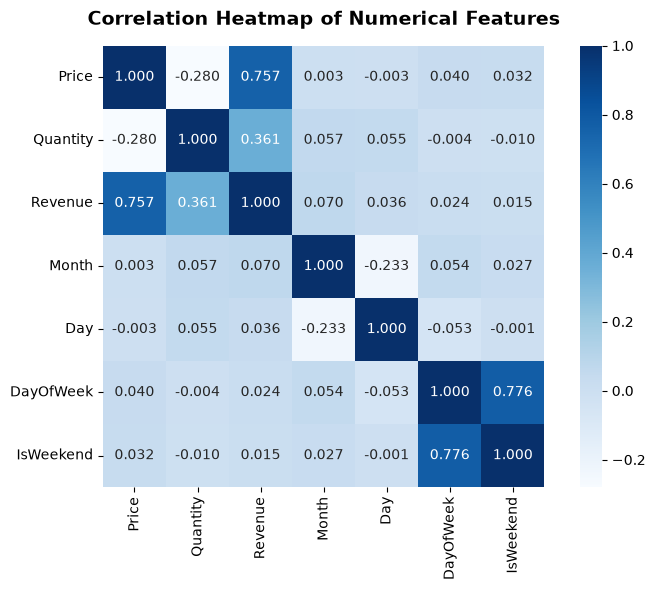

In [69]:
# Correlation Heatmap

plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, fmt=".3f", cmap='Blues', cbar=True, square=True)
plt.title('Correlation Heatmap of Numerical Features', fontsize=14, fontweight='bold', pad=15)
plt.tight_layout()
plt.show()


การแปรผล

1. Price มีผลต่อยอดขายอย่างมีนัยยะสำคัญ ค่า r = 0.757 หมายถึง ราคาต่อหน่วยของสินค้า เป็นส่วนสำคัญที่ทำให้ยอดขายรวมสูง
2. จำนวนชิ้นที่ขายได้กับยอดขาย มีทิศทางเดียวกัน แต่ไม่มีผลมาก
3. Revenue ไม่ได้รับผลกระทบจากช่วงเวลา
ความสัมพันธ์อื่น ๆ ที่น่าาสนใจ
Price กับ Quantity มีผลเชิงลบ ตามความเป็นจริง เมื่อราคาสูงขึ้น จำนวนการซื้อจะลดลง
DayOfWeek กับ IsWeekend มีผลเชิงบวก เพราะ  IsWeekend มาจาก DayOfWeek ต้องระวังตอนทำโมเดล

มุมมองที่ 2: ยอดขายจำแนกตามประเภทสินค้า

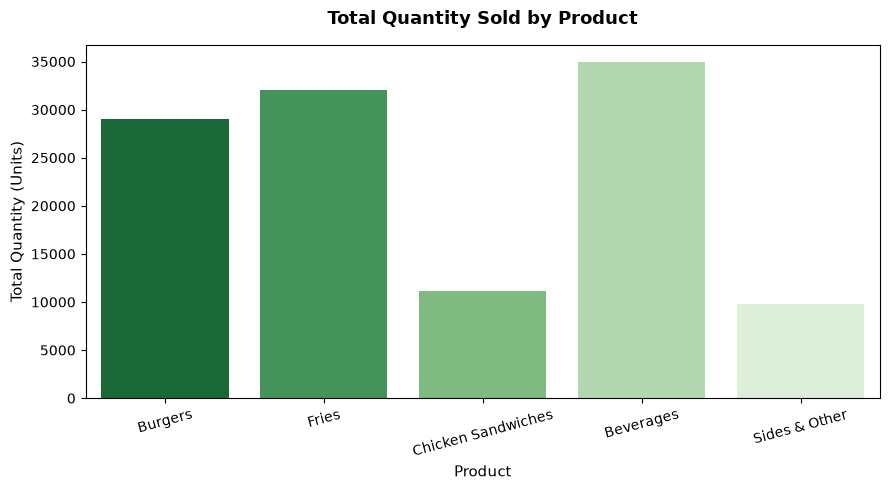

In [70]:
plt.figure(figsize=(9, 5))

# พล็อตกราฟแท่ง Total Quantity
ax = sns.barplot(
    data= product_summary,
    x='Product',
    y='Total_Quantity',
    hue='Product',
    palette='Greens_r',
    legend=False
)

plt.title('Total Quantity Sold by Product', fontsize=13, fontweight='bold', pad=15)
plt.xlabel('Product', fontsize=11)
plt.ylabel('Total Quantity (Units)', fontsize=11)
plt.xticks(rotation=15)


plt.tight_layout()
plt.show()

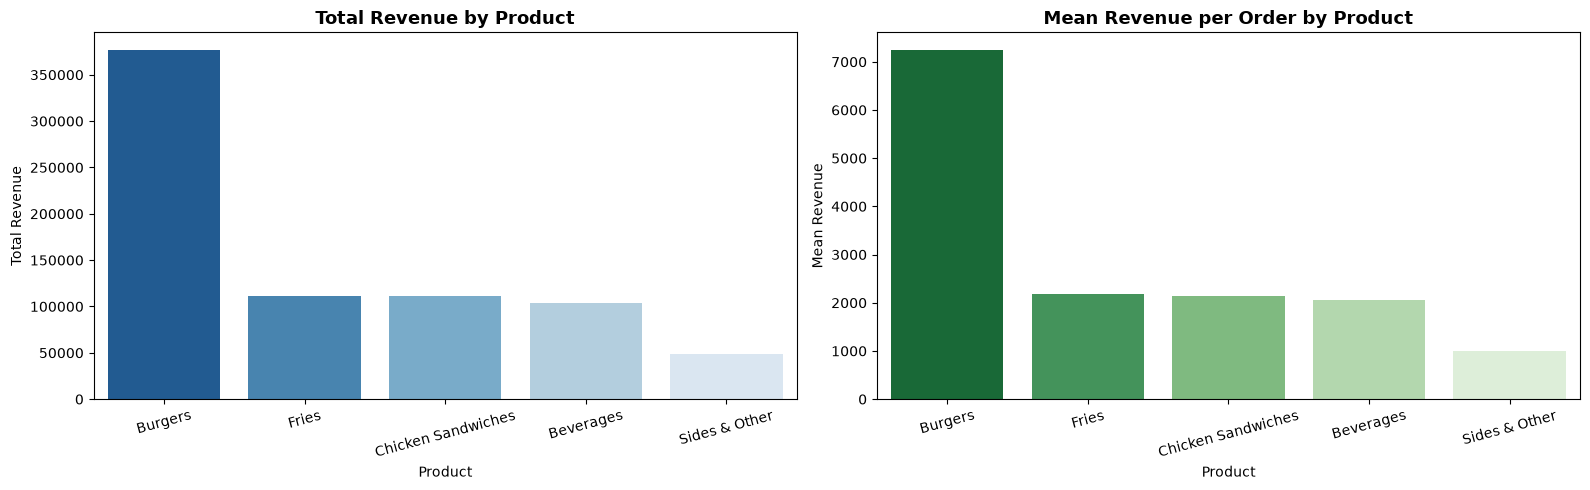

In [71]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(
    data=product_summary,
    x='Product',
    y='Total_Revenue',
    hue='Product',
    palette='Blues_r',
    legend=False,
    ax=axes[0]
)
#ยอดขายรวมทั้งหมดแยกตามประเภทสินค้า
axes[0].set_title('Total Revenue by Product',fontsize=13,fontweight='bold')
axes[0].set_xlabel('Product')
axes[0].set_ylabel('Total Revenue')
axes[0].tick_params(axis='x', rotation=15)

# มูลค่ายอดขายเฉลี่ยที่ได้รับต่อ 1 ออเดอร์ของสินค้าแต่ละประเภท
product_summary['Mean_Revenue'] = product_summary['Total_Revenue'] / product_summary['Order_Count']
product_mean = product_summary.sort_values(by='Mean_Revenue', ascending=False)
sns.barplot(
    data = product_mean,
    x = 'Product',
    y = 'Mean_Revenue',
    hue = 'Product',
    palette = 'Greens_r',
    legend = False,
    ax = axes[1]
)

axes[1].set_title('Mean Revenue per Order by Product', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Product')
axes[1].set_ylabel('Mean Revenue')
axes[1].tick_params(axis='x', rotation=15)

# จัดระยะห่าง
plt.tight_layout()

# แสดงกราฟ
plt.show()

แปรผล
กราฟยอดขายรวมทั้งหมดแยกตามประเภทสินค้า และ ยอดขายต่อออร์เดอร์ 1 ประเภท แสดงให้เห็นว่า Burgers เป็น เมนูที่ยอดขายสูงที่สุด  และถูกสั่งซื้อมากที่สุด แม้ว่า
จำนวนการสั่งซื้อ ของ Beverages และ Fries จะมีมากกว่า แต่ราคาต่อหน่วยต่ำ ทำให้ Burgers ที่่เป็นสินค้ามีราคาที่สูงพร้อมกับจำนวนการสั่งซื้อมีมาก ทำให้ยอดขายรวมสูงกว่า

มุมมองที่ 3: ยอดขายจำแนกตามช่องทางการซื้อ (Revenue by Purchase Type) 


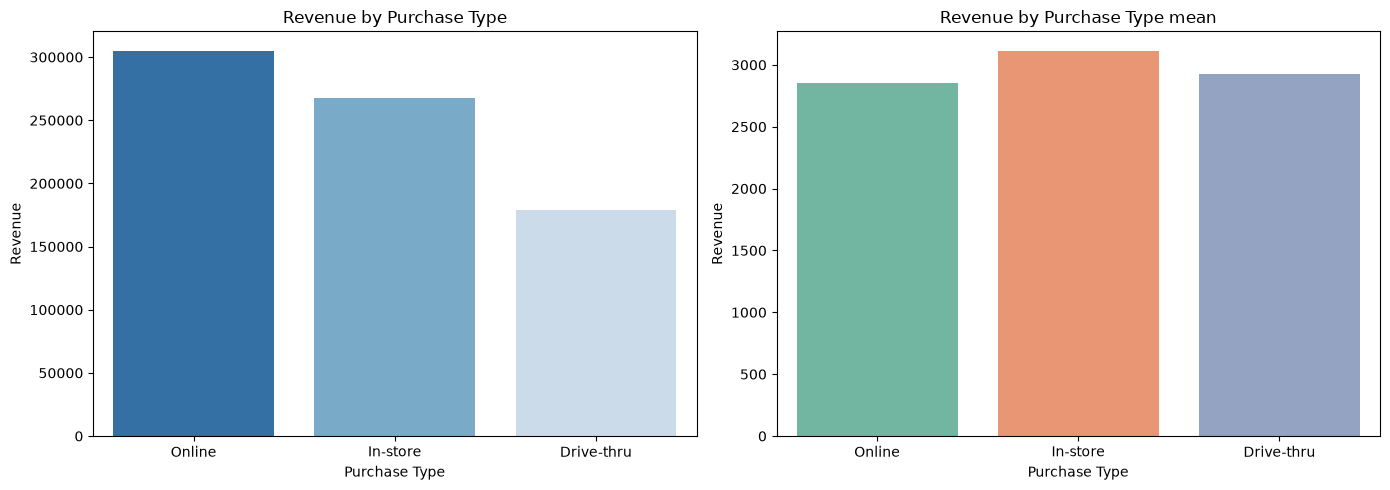

In [72]:
#สรุปยอดขายตามช่องทางการซื้อ
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].set_title('Revenue by Purchase Type')
ax = sns.barplot(
    data = CleanR,              # ชื่อ DataFrame หรือข้อมูลที่ต้องการนำมาพล็อต
    x = 'Purchase Type',       # ข้อมูลในแกน X (มักเป็นข้อมูลเชิงกลุ่ม/Categorical)
    y = 'Revenue',       # ข้อมูลในแกน Y (มักเป็นข้อมูลตัวเลข/Numerical)
    hue = 'Purchase Type',  # (Optional) คอลัมน์ที่ใช้จำแนกสีเพิ่ม
    palette = 'Blues_r',    # (Optional) โทนสีของกราฟ เช่น 'Blues_r', 'Set2', 'viridis'
    estimator = 'sum',      # (Optional) ฟังก์ชันคำนวณค่าแกน Y เช่น 'mean' (ค่าเริ่มต้น) หรือ 'sum'
    errorbar = None,        # (Optional) ปิด/เปิด เส้นขีดค่าความคลาดเคลื่อน (Confidence Interval)
    legend = False,          # (Optional) แสดงหรือซ่อนกล่องอธิบายสัญลักษณ์ (Legend)
    ax = axes[0]
)


axes[1].set_title('Revenue by Purchase Type mean')
ax = sns.barplot(
    data = CleanR,  
    x = 'Purchase Type',   
    y = 'Revenue', 
    hue = 'Purchase Type', 
    palette = 'Set2',  
    estimator = 'mean',
    errorbar =  None,
    legend = False,  
    ax = axes[1]
)

plt.tight_layout()

แปรผล
สำหรับกราฟแรก ยอดขายรวม ทำยอดขายผ่านช่องทาง online ได้สูงที่สุด เนื่องจากมีความถี่ในการสั่งซื้อจำนวนมาก (107 ครั้ง)
แต่ค่าเฉลี่ยยอดขายต่อรายการกลับเป็นช่องทาง ในร้านค้า เนื่องจากผู้สั่งซื้อจะสั่งซื้อต่อบิลในราคารวมที่สูงกว่า

มุมมองที่ 4 ยอดขายสินค้ากับเมืองต่าง ๆ

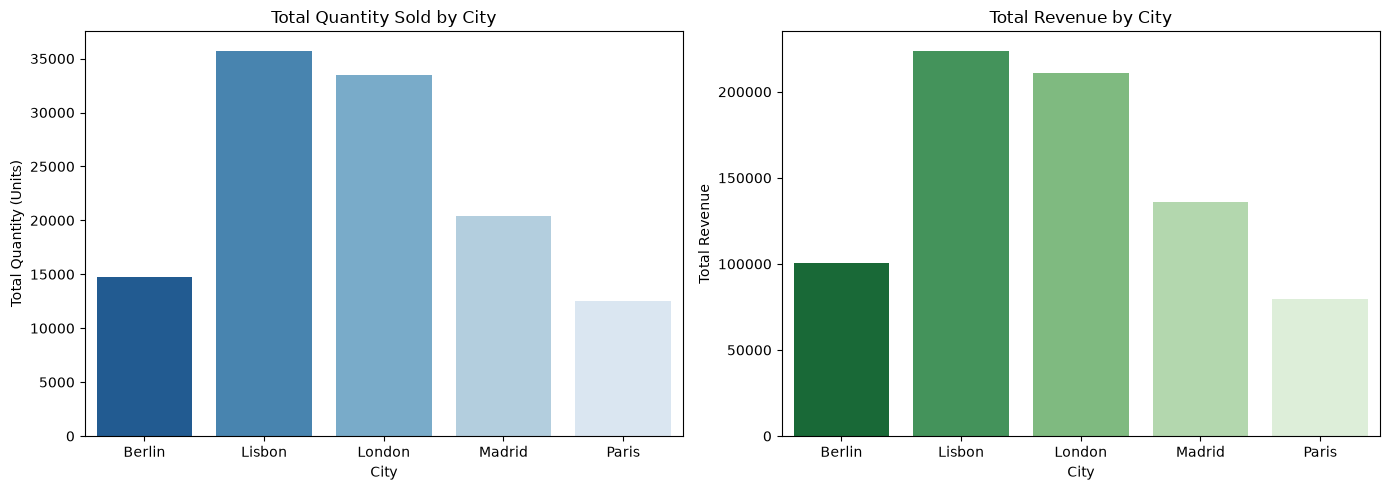

In [73]:
city_summary = CleanR.groupby('City').agg(
    Total_Quantity=('Quantity', 'sum'),
    Total_Revenue=('Revenue', 'sum')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# กราฟที่ 1  จำนวนชิ้นรวมตามเมือง 
sns.barplot(
    data=city_summary,
    x='City',
    y='Total_Quantity',
    hue='City',
    palette='Blues_r',
    legend=False,
    ax=axes[0]  
)
axes[0].set_title('Total Quantity Sold by City', fontsize=12)
axes[0].set_xlabel('City')
axes[0].set_ylabel('Total Quantity (Units)')

#กราฟที่ 2ยอดขายรวมตามเมือง 
sns.barplot(
    data=city_summary,
    x='City',
    y='Total_Revenue',
    hue='City',
    palette='Greens_r',
    legend=False,
    ax=axes[1]
)
axes[1].set_title('Total Revenue by City', fontsize=12)
axes[1].set_xlabel('City')
axes[1].set_ylabel('Total Revenue')

plt.tight_layout()
plt.show()

แปรผล
จำนวนรวมที่ขายสินค้าได้ และยอดขายรวมที่ขายได้ ในแต่ละเมือง สอดคล้องกัน โดยมี Lisbon และ London ที่เป็นสองสาขาหลักที่ทำยอดขายได้มากที่สุด

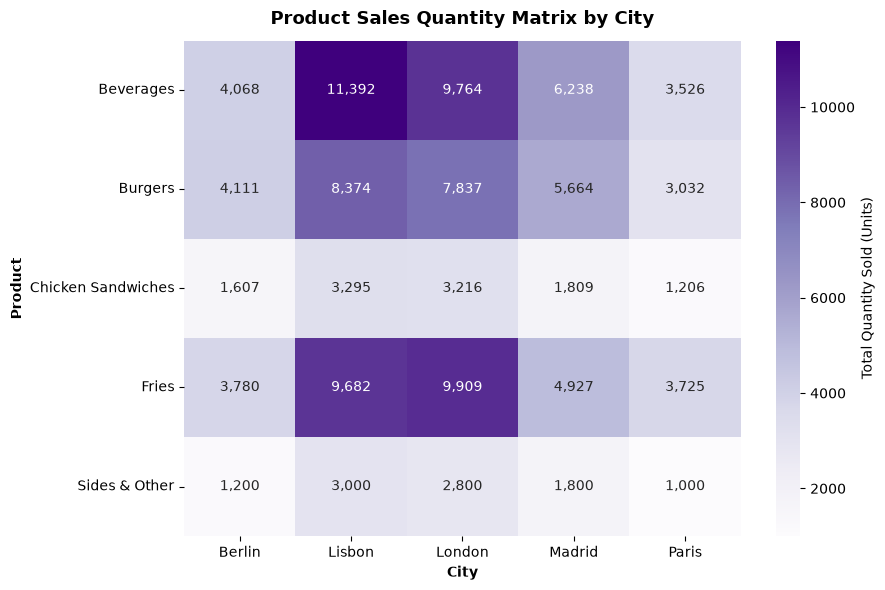

In [74]:
pivot = pd.crosstab(
    CleanR['Product'],
    CleanR['City'],
    values=CleanR['Quantity'],
    aggfunc='sum'
)

plt.figure(figsize=(9, 6))

sns.heatmap(
    pivot,
    annot=True,
    fmt=',.0f',
    cmap='Purples',
    cbar_kws={'label': 'Total Quantity Sold (Units)'}
)

plt.title(
    'Product Sales Quantity Matrix by City',
    fontsize=13,
    fontweight='bold',
    pad=12
)

plt.xlabel('City', fontweight='bold')
plt.ylabel('Product', fontweight='bold')

plt.tight_layout()
plt.show()

แปรผล
สินค้า Beverages  ในเมือง Lisbon ขายดีที่สุด ถัดมาภายในเมือง คือ Fries และ Burgers

สินค้า Sides and other ในเมือง Paris มีการขายได้น้อยที่สุด

ไม่มีการนำ Manager มาพิจารณาต่อ เนื่องจาก ผู้จัดกรแต่บละคนจะประจำอยู่ที่สาขแต่ละเมือง เท่านั้น ทำให้มีค่าเท่ากับร้านในแต่ละเมือง

พิจารณาวันในแต่ละสัปดาห์ คู่กับยอดรวมรายได้

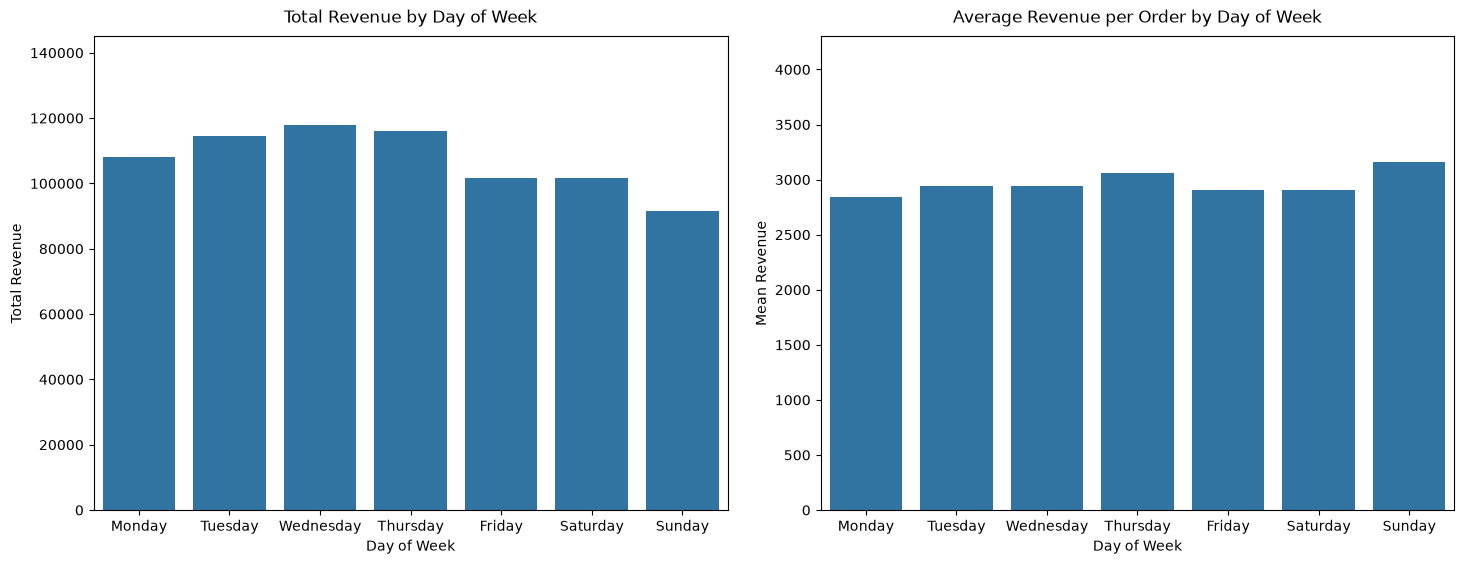

In [75]:
CleanR['DayName'] = CleanR['Date'].dt.day_name()

# สรุปข้อมูลรายวัน
day_summary = CleanR.groupby(['DayOfWeek', 'DayName']).agg(
    Total_Revenue=('Revenue', 'sum'),
    Order_Count=('Order ID', 'count'),
    Mean_Revenue=('Revenue', 'mean')
).reset_index().sort_values('DayOfWeek')

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data = day_summary, x = "DayName", y = "Total_Revenue", legend = False, ax = axes[0])

axes[0].set_title("Total Revenue by Day of Week", fontsize=12, pad=10)
axes[0].set_xlabel("Day of Week")
axes[0].set_ylabel("Total Revenue")
axes[0].set_ylim(0, 145000)

sns.barplot(data = day_summary, x = "DayName", y = "Mean_Revenue", legend = False, ax = axes[1])

axes[1].set_title("Average Revenue per Order by Day of Week", fontsize=12, pad = 10)
axes[1].set_xlabel("Day of Week")
axes[1].set_ylabel("Mean Revenue")
axes[1].set_ylim(0, 4300)

plt.tight_layout(pad=2.0)
plt.show()

ช่วงต้นสัปดาห์มียอดขายรวมสูงกว่าช่วงท้ายสัปดาห์ แต่ ค่าเฉลี่ยยอดขายจากแต่ละออเดอร์ จะสังเกตว่าวันอาทิตย์ที่เป็นวันหยุด มียอดขายต่อบิลที่สูงกว่า อาจเพราะวันธรรมดา เน้นการขายในปริมาณมาก แต่วันหยุด คนซื้อน้อยลงเนื่องจากไม่ออกจากบ้าน และหากมีการซื้อก็จะมีการซื้อปริมาณมาก อาจเป็นการซื้อทานอาหารร่วมกันในวันหยุด


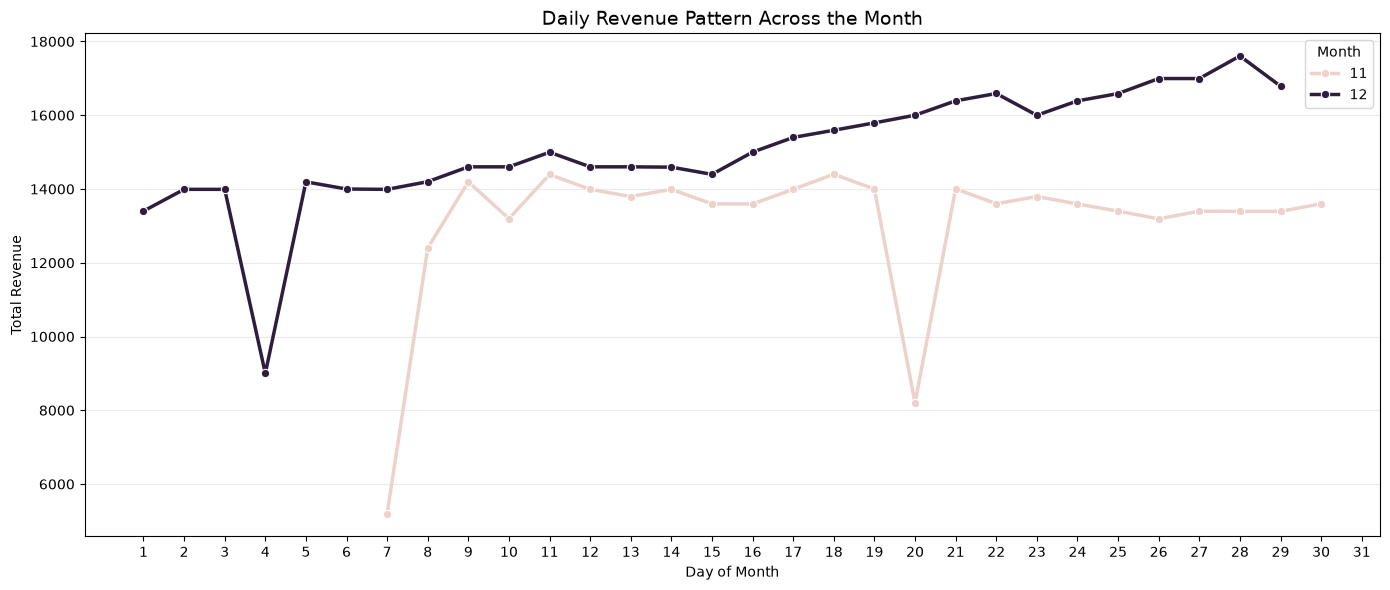

In [76]:
# สรุปยอดขายตามวันที่ในเดือน
monthly_day = (
    CleanR.groupby(['Month', 'Day'])
    .agg(
        Total_Revenue=('Revenue', 'sum'),
        Order_Count=('Order ID', 'count')
    )
    .reset_index()
)

# กราฟเส้นเปรียบเทียบ 2 เดือน
plt.figure(figsize=(14, 6))

sns.lineplot(data = monthly_day,
    x = 'Day',
    y = 'Total_Revenue',
    hue = 'Month',
    marker = 'o',
    linewidth = 2.5
)

plt.title('Daily Revenue Pattern Across the Month',fontsize=14)
plt.xlabel('Day of Month')
plt.ylabel('Total Revenue')

plt.xticks(range(1, 32))
plt.grid(axis='y', alpha=0.25)

plt.legend(title='Month')
plt.tight_layout()
plt.show()

จากกราฟ สังเกตได้ว่า ยอดขายช่วงเทศกาลคริสต์มาส และใกล้สิ้นปีมีอัตราการเติบโตที่สูงขึ้นเล็กน้อยในช่วงต้นเดือนทั้งสองเดือนที่ผ่านมา

In [77]:
ความสัมพันธ์ของวิธีการชำระเงินและช่องทางการซื้อ

NameError: name 'ความสัมพันธ์ของวิธีการชําระเงินและช่องทางการซื้อ' is not defined

In [ ]:
payment_purchase = pd.crosstab(
    CleanR['Payment Method'],
    CleanR['Purchase Type'],
    normalize='index'
) * 100

plt.figure(figsize=(9, 6))

sns.heatmap(
    payment_purchase,
    annot=True,
    fmt='.1f',
    cmap='Blues'
)

plt.title('Payment Method vs Purchase Type (%)',
          fontsize=13, fontweight='bold')

plt.xlabel('Purchase Type')
plt.ylabel('Payment Method')

plt.tight_layout()
plt.show()

In [ ]:
แปรผล
วิธีการชำระเงินมีความสัมพันธ์กับช่องทางการซื้อ คือ
1. การชำระด้วยเงินสด มักใช้งานผ่านการซื้อภายในร้านค้า
2. การใช้ Gift Card ใช้งานผ่านการซื้ออนไลน์เป็นหลัก
3. การใช้ Credit Card เฉลี่ยนช่องทางการชำระเงินใกล้เคียงกัน

**statsmodels**

In [78]:
#import statsmodels.formula.api as sm

In [79]:
formula = 'Revenue ~ Price + Quantity + C(Product) + C(Q("Purchase Type")) + C(Q("Payment Method")) + C(City)'
ols_model = sm.ols(formula=formula, data=CleanR).fit()
print(ols_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     3806.
Date:                Sun, 27 Sep 2026   Prob (F-statistic):          1.19e-269
Time:                        18:49:01   Log-Likelihood:                -1645.4
No. Observations:                 254   AIC:                             3319.
Df Residuals:                     240   BIC:                             3368.
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                            coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------

**การแปรผล**
R-squared:  0.995
Adj. R-squared:  0.995
ตัวแปรอิสระทุกตัวในโมเดลมีผลต่อRevenue

ตัวแปรอิสระทุกตัวในโมเดลมีค่า p-value น้อยกว่า 0.05 ทุกตัว หมายความว่า ทุกปัจจัยส่งผลต่อ Revenue อย่างมีนัยสำคัญทางสถิติ

ค่า coef ของเมือง Lisbon london Paris มีค่าเป็นลบ เมื่อควบคุม ราคาและปริมาณการขายแล้ว ประสิทธิภาพเชิงราคาต่อหน่วยของ Lisbon London จึงต่ำกว่า Berlin แสดงว่า ที่ Lisbon London มีราคารวมมาก เกิดจาก ปริมาณการขาย สินค้าที่มีราคาสูง มีมากกว่า

In [80]:
predicted_revenue = ols_model.predict()

osl_result = pd.DataFrame({
    'Actual Revenue': CleanR['Revenue'],
    'Predicted Revenue': predicted_revenue,
    'Difference (Error)': CleanR['Revenue'] - predicted_revenue
})
osl_result.head(10)

,Actual Revenue,Predicted Revenue,Difference (Error)
0,1999.77,1643.500464,356.269536
1,2200.70,2559.514792,-358.814792
2,998.00,1037.362436,-39.362436
3,7404.30,7527.715022,-123.415022
4,1999.95,2150.881867,-150.931867
5,1999.77,1687.278393,312.491607
6,998.00,1154.098120,-156.098120
7,7196.46,7271.813465,-75.353465
8,1999.95,2059.564441,-59.614441
9,1999.77,1687.278393,312.491607


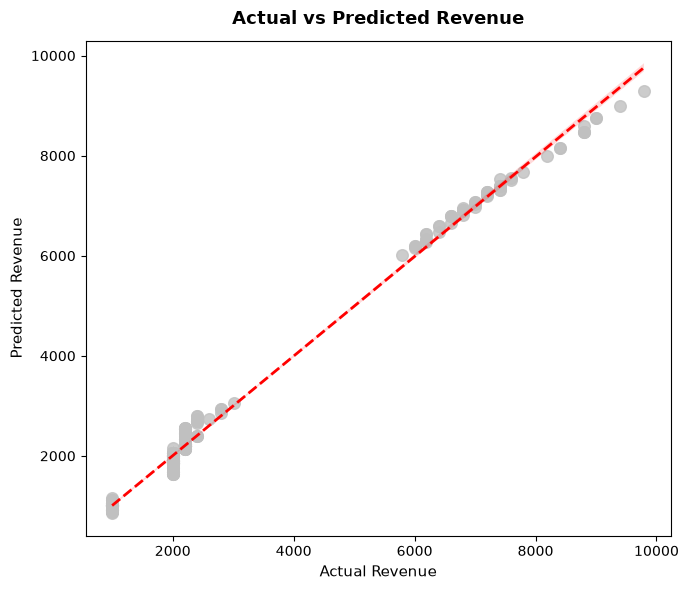

In [81]:
plt.figure(figsize=(7, 6))

sns.regplot(
    x =  CleanR['Revenue'],
    y = predicted_revenue,
    scatter_kws={'alpha': 0.8, 'color': 'Silver', 's': 70},
    line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2}
)

plt.title('Actual vs Predicted Revenue', fontsize=13, fontweight='bold', pad=12)
plt.xlabel('Actual Revenue', fontsize=11)
plt.ylabel('Predicted Revenue', fontsize=11)
plt.tight_layout()

plt.show()

รูปแบบ Scikit learn

#**Encoding**

In [82]:
# คัดลอก DataFrame สำหรับทำโมเดล
res_encode = CleanR.copy()

# One-Hot Encoding
categorical_cols = ['Product', 'Purchase Type', 'Payment Method', 'City']
res_encode = pd.get_dummies(res_encode, columns = categorical_cols,
                                  drop_first = True, dtype = int)
# drop_first=True ลบcol แรก ใช้ Drive-thru เป็นค่าเปรียบเทียบ (Baseline): โมเดลจะดูว่าการซื้อแบบ In-store หรือ Online ได้ยอดขาย "เพิ่มขึ้นหรือลดลงเท่าไร เมื่อเทียบกับ Drive-thru"

res_encode.head()

,Order ID,Date,Price,Quantity,Manager,Month,Day,DayOfWeek,IsWeekend,Revenue,...,Product_Fries,Product_Sides & Other,Purchase Type_In-store,Purchase Type_Online,Payment Method_Credit Card,Payment Method_Gift Card,City_Lisbon,City_London,City_Madrid,City_Paris
0,10452,2022-11-07,3.49,573,Tom Jackson,11,7,0,0,1999.77,...,1,0,0,1,0,1,0,1,0,0
1,10453,2022-11-07,2.95,746,Pablo Perez,11,7,0,0,2200.70,...,0,0,0,1,0,1,0,0,1,0
2,10454,2022-11-07,4.99,200,Joao Silva,11,7,0,0,998.00,...,0,1,1,0,0,1,1,0,0,0
3,10455,2022-11-08,12.99,570,Walter Muller,11,8,1,0,7404.30,...,0,0,1,0,1,0,0,0,0,0
4,10456,2022-11-08,9.95,201,Walter Muller,11,8,1,0,1999.95,...,0,0,1,0,1,0,0,0,0,0


In [83]:
res_encode.info()

<class 'pandas.DataFrame'>
RangeIndex: 254 entries, 0 to 253
Data columns (total 23 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Order ID                    254 non-null    int64         
 1   Date                        254 non-null    datetime64[us]
 2   Price                       254 non-null    float64       
 3   Quantity                    254 non-null    int64         
 4   Manager                     254 non-null    str           
 5   Month                       254 non-null    int32         
 6   Day                         254 non-null    int32         
 7   DayOfWeek                   254 non-null    int32         
 8   IsWeekend                   254 non-null    int64         
 9   Revenue                     254 non-null    float64       
 10  DayName                     254 non-null    str           
 11  Product_Burgers             254 non-null    int64         
 12  Produ

**เตรียมข้อมูลสำหรับทำModel**

ชุดข้อมูลมีทั้งหมด 54 วัน แบ่งข้อมูลออกเป็น 80:20 โดยได้ประมาณ 43 วัน ต่อ 11 วัน

In [104]:
# กำหนดจุดตัดวันที่ กำหนด ข้อมูล
split_date = pd.Timestamp('2022-12-18')

# แบ่ง train และ test
train = CleanR[CleanR['Date'] < split_date].copy()
test = CleanR[CleanR['Date'] >= split_date].copy()

In [105]:
features = [
    'Price',
    'Quantity',
    'Day',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'Product_Chicken Sandwiches',
    'Product_Fries',
    'Product_Sides & Other',
    'Purchase Type_In-store',
    'Purchase Type_Online',
    'Payment Method_Credit Card',
    'Payment Method_Gift Card',
    'City_Lisbon',
    'City_London',
    'City_Madrid',
    'City_Paris',
]
target = 'Revenue'
valid_features = [f for f in features if f in train.columns]

# ดึง X, y แยกสำหรับ Train และ Test
X_train = train[valid_features]
y_train = train[target]

X_test = test[valid_features]
y_test = test[target]

**เริ่มต้น Training**

In [106]:
#from sklearn.linear_model import LinearRegression
#from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

In [107]:
res_model = LinearRegression()

res_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[507.32, 6.21, -5.5 ,-10.24, 28.01, -5.61]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['Price','Quantity','Day','DayOfWeek','Month','IsWeekend']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-3684
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [108]:
y_pred_train = res_model.predict(X_train)
y_pred_test = res_model.predict(X_test)

#print(y_pred_train)
#print(y_pred_test)

ทดสอบประสิทธิภาพโมเดล

In [109]:
r2_train = r2_score(y_train, y_pred_train)
r2_test  = r2_score(y_test, y_pred_test)

#คำนวณ RMSE

rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
mae_test = mean_absolute_error(y_test, y_pred_test)

print("R2 Train :", r2_train)
print("2² Test  :", r2_test)
print("RMSE     :", rmse_test)
print("MAE      :", mae_test)


R2 Train : 0.9294860827705007
2² Test  : 0.9148763238437642
RMSE     : 814.9246062409508
MAE      : 628.8799080945463


แปรผล
R-squared: 0.929 ตัวแปรอิสระทุกตัวในโมเดลมีผลต่อRevenue
ค่า MAE ความคลาดเคลื่อน ของการประมวลผล อยู่ที่ประมาณ 629 บาท ซึ่ง ค่า RMSE แสดงให้เห็นว่าโอกาสคาดเคลื่อนสูงสุดที่ 814 บาท อาจเกิดจากช่วงเวลาที่เป็นวันหยุดทำให้ขายได้มากขึ้น

In [110]:
res_model_result = pd.DataFrame({
    'Actual Revenue': y_test,
    'Predicted Revenue': y_pred_test,
    'Difference (Error)': y_test - y_pred_test
})

res_model_result.head(10)

,Actual Revenue,Predicted Revenue,Difference (Error)
195,7794.00,6804.529593,989.470407
196,2198.95,2907.218204,-708.268204
197,2401.12,2531.806607,-130.686607
198,2200.70,2618.258159,-417.558159
199,998.00,260.417764,737.582236
200,8196.69,7058.709486,1137.980514
201,2198.95,2968.768073,-769.818073
202,2198.70,2232.951912,-34.251912
203,2200.70,2679.808028,-479.108028
204,998.00,321.967632,676.032368


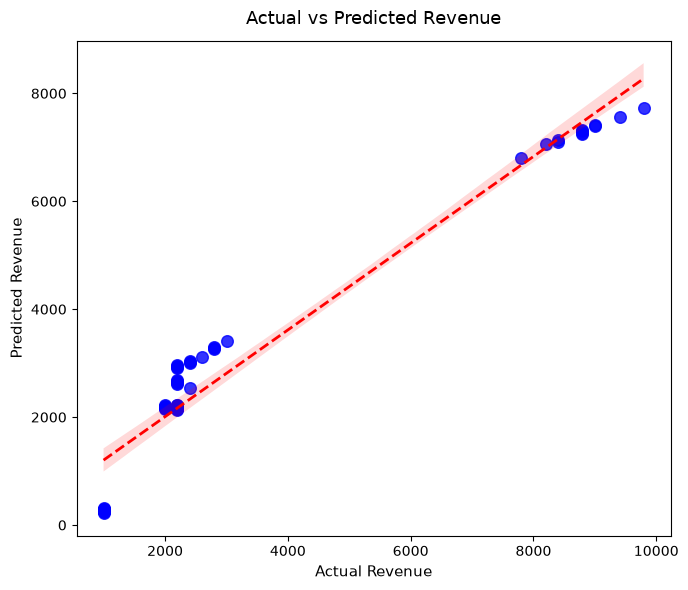

In [112]:
plt.figure(figsize=(7, 6))

sns.regplot(
    x=y_test,
    y=y_pred_test,
    scatter_kws={'alpha': 0.8, 'color': 'blue', 's': 70},
    line_kws={'color': 'red', 'linestyle': '--', 'linewidth': 2}
)

plt.title('Actual vs Predicted Revenue', fontsize=13, pad=12)
plt.xlabel('Actual Revenue', fontsize=11)
plt.ylabel('Predicted Revenue', fontsize=11)
plt.tight_layout()

plt.show()

แปรผล

จากการวิเคราะห์โมเดลพยากรณ์ทั้งสองรูปแบบ พบว่ามีความแม่นยำสูง ด้วยค่า R2 =  0.995 ซึ่งอาจเกิดจาก ตัวแปร Revenue ประกอบตัวตัวแปรอิสระ Price และ Quantity ที่เป็นวิธีคำนวณตามปกติ 

ทดสอบโมเดลเมื่อเพิ่มปัจจัย เกี่ยวกับ วัน เดือน วันหยุด เข้าไปในสมการ 

In [113]:
#สูตร OLS โดยเพิ่มตัวแปร Is_Weekend, DayOfWeek และ Month
# หมายเหตุ: หาก DayOfWeek และ Month เป็นข้อมูลเชิงกลุ่ม (Categorical) ควรใส่ C() ครอบไว้ด้วย
formula_with_time = '''    Revenue ~ Price + Quantity + C(Product)  + C(Q("Purchase Type")) + C(City) 
    + IsWeekend 
    + C(DayOfWeek) 
    + C(Month)
'''

ols_time_model = sm.ols(formula=formula_with_time, data=CleanR).fit()

# 3. แสดงผลการวิเคราะห์ทางสถิติ
print(ols_time_model.summary())

                            OLS Regression Results                            
Dep. Variable:                Revenue   R-squared:                       0.995
Model:                            OLS   Adj. R-squared:                  0.995
Method:                 Least Squares   F-statistic:                     2780.
Date:                Sun, 27 Sep 2026   Prob (F-statistic):          1.83e-262
Time:                        18:55:21   Log-Likelihood:                -1641.3
No. Observations:                 254   AIC:                             3321.
Df Residuals:                     235   BIC:                             3388.
Df Model:                          18                                         
Covariance Type:            nonrobust                                         
                                        coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------
Interc

ผลลัพธ์พบว่า วัน เดือน และวันหยุด ไม่ได้ส่งผลต่อโมเดลอย่างมีนัยยะสำคัญ ตรงตามการสำรวจข้อมูลเบื้องต้นที่ทำไว้ก่อนหน้า

*หากเราใส่เฉพาะปัจจัยด้านช่วงเวลาอย่างเดียว (* *Day* *,* *DayOfWeek* *,* *Month* *) โดยไม่มีปัจจัยเรื่องชนิดสินค้า ราคา หรือช่องทางขาย โมเดลจะสามารถพยากรณ์ยอดขายได้หรือไม่ เนื่องจาก การขายสินค้าจริงเราไม่อาจทราบได้ว่าจะขายได้เท่าไหร่บ้าง*

In [114]:
# กรณี การทดลองเปรียบเทียบ 
features = ['Day', 'DayOfWeek', 'Month']
target = 'Revenue'

# ดึง X, y แยกสำหรับ Train และ Test
IF_X_train = train[features]
IF_y_train = train[target]

IF_X_test = test[features]
IF_y_test = test[target]

# สร้างและเทรนโมเดล
IF_res_model = LinearRegression()
IF_res_model.fit(IF_X_train, IF_y_train)

# ทำการ Predict
IF_y_pred_train = IF_res_model.predict(IF_X_train)
IF_y_pred_test = IF_res_model.predict(IF_X_test)

# คำนวณ R2 Score
IF_r2_train = r2_score(IF_y_train, IF_y_pred_train)
IF_r2_test = r2_score(IF_y_test, IF_y_pred_test)

# คำนวณ RMSE และ MAE
IF_rmse_test = np.sqrt(mean_squared_error(IF_y_test, IF_y_pred_test))
IF_mae_test = mean_absolute_error(IF_y_test, IF_y_pred_test)

print("R2 Train :", IF_r2_train)
print("R2 Test  :", IF_r2_test)
print("RMSE     :", IF_rmse_test)
print("MAE      :", IF_mae_test)

R2 Train : 0.002653890251303692
R2 Test  : -0.02979246152092041
RMSE     : 2834.4389025869577
MAE      : 1931.334589611892


แปรผล

R² ต่ำมากทั้ง train และ test  แสดงว่าปัจจัยด้านวันและเดือนเพียงอย่างเดียวไม่เพียงพอในการพยากรณ์มูลค่ายอดขายรายออเดอร์

**ทดลองสร้างโมเดลพยากรณ์  Quantity โดยตัด Price ออก เนื่องจากการพยากรณ์ยอดขาย เกิดจาก ราคาต่อหน่วย * จำนวนสินค้าที่ขายได้**

In [120]:
# แบ่ง train และ test
train = CleanR[CleanR['Date'] < split_date].copy()
test = CleanR[CleanR['Date'] >= split_date].copy()

Qfeatures = [
    'Day',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'Product_Chicken Sandwiches',
    'Product_Fries',
    'Product_Sides & Other',
    'Purchase Type_In-store',
    'Purchase Type_Online',
    'Payment Method_Credit Card',
    'Payment Method_Gift Card',
    'City_Lisbon',
    'City_London',
    'City_Madrid',
    'City_Paris',
]
Qtarget = 'Quantity'
Qvalid_features = [f for f in Qfeatures if f in train.columns]

# ดึง X, y แยกสำหรับ Train และ Test
QX_train = train[Qvalid_features]
Qy_train = train[Qtarget]

QX_test = test[Qvalid_features]
Qy_test = test[Qtarget]

Qres_model = LinearRegression()

Qres_model.fit(QX_train, Qy_train)

Qy_pred_train = Qres_model.predict(QX_train)
Qy_pred_test = Qres_model.predict(QX_test)

Qr2_train = r2_score(Qy_train, Qy_pred_train)
Qr2_test  = r2_score(Qy_test, Qy_pred_test)

#คำนวณ RMSE

Qrmse_test = np.sqrt(mean_squared_error(Qy_test, Qy_pred_test))
Qmae_test = mean_absolute_error(Qy_test, Qy_pred_test)

print("R2 Train :", Qr2_train)
print("R2 Test  :", Qr2_test)
print("RMSE     :", Qrmse_test)
print("MAE      :", Qmae_test)


R2 Train : 0.00043474025349032885
R2 Test  : -0.029706271548005425
RMSE     : 223.92895903229686
MAE      : 220.32750670230536


ผลคือ R² ต่ำมากทั้ง train และ test แสดงว่าปัจจัย เรื่องเวลา ช่องทาง เมือง วิธีจ่าย ไม่เพียงพอต่อการอธิบายความแปรปรวนของ Quantity
อาจเป็นเพราะข้อจำกัดของชุดข้อมูล (จำนวนตัวอย่างน้อย ~254 แถว, หรือข้อมูลถูกสุ่มสร้างขึ้นโดยไม่มี pattern พฤติกรรมจริงฝังอยู่) มากกว่าเป็นข้อจำกัดของ Linear Regression เอง

ทดสอบความสัมพันธ์ของ Quantity กับปัจจัยอื่น ๆ

In [121]:
Qres_model.coef_

array([ 0.54115524,  0.916963  , 10.18699336, -5.98615589])

In [122]:
Qres_model_coef = pd.DataFrame({
    'Feature': QX_train.columns,
    'Coefficient': Qres_model.coef_
})

print(Qres_model_coef)

     Feature  Coefficient
0        Day     0.541155
1  DayOfWeek     0.916963
2      Month    10.186993
3  IsWeekend    -5.986156


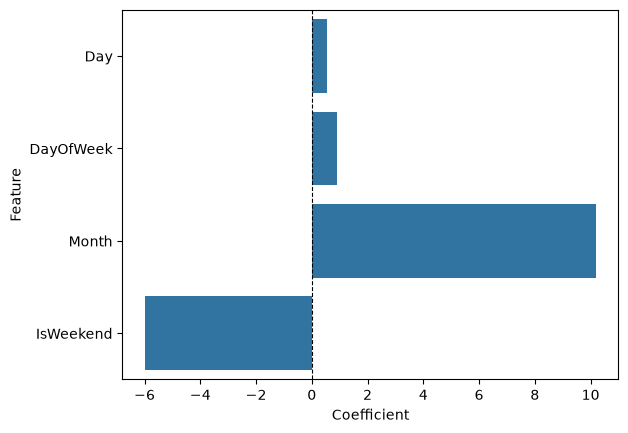

In [123]:
sns.barplot(
    data = Qres_model_coef,
    x = 'Coefficient',
    y = 'Feature',
    errorbar=None
)
plt.axvline(x=0, color='black', linestyle='--', linewidth=0.8)

แปรผล
เดือน มีผลต่อจำนวนสินค้า หมายถึง ช่วงปลายเดือนมีปริมาณการซื้อที่เพิ่มขึ้น ส่วนวันและสัปดาห์มีผลค่อนข้างน้อย
ช่วงวันหยุดไม่มีความสัมพันธ์กับปริมาณการขาย เนื่องจากลูกค้าอาจไม่นิยมซื้อสินค้าชนิดนี้ในช่วงวันหยุด